# **Pytorch Dataset & Dataloader :**

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT)
)

In [2]:
from src.fod_dataset import (
    FODDetectionDataset,
    create_dataloader
)

In [3]:
YOLO_ROOT = (
    PROJECT_ROOT /
    "dataset" /
    "yolo"
)

print(YOLO_ROOT)

d:\IZI\dataset\yolo


In [5]:
# # * Train Dataset :

train_dataset = FODDetectionDataset(
    root_dir=YOLO_ROOT,
    split="train",
    img_size=640
)

print(
    "Training images:",
    len(train_dataset)
)

Training images: 20235


In [6]:
# # * Val Dataset :

val_dataset = FODDetectionDataset(
    root_dir=YOLO_ROOT,
    split="val",
    img_size=640
)

print(
    "Validation images:",
    len(val_dataset)
)

Validation images: 5059


In [7]:
# # * test Dataset :

test_dataset = FODDetectionDataset(
    root_dir=YOLO_ROOT,
    split="test",
    img_size=640
)

print(
    "Test images:",
    len(test_dataset)
)

Test images: 8429


In [8]:
image, target = train_dataset[0]

In [9]:
print("Image shape:", image.shape)

print(
    "Boxes shape:",
    target["boxes"].shape
)

print(
    "Labels shape:",
    target["labels"].shape
)

print(
    "Image ID:",
    target["image_id"]
)

print(
    "Boxes:",
    target["boxes"]
)

print(
    "Labels:",
    target["labels"]
)

Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([1, 4])
Labels shape: torch.Size([1])
Image ID: 000000
Boxes: tensor([[294.8736, 222.4711, 323.0733, 316.4743]])
Labels: tensor([2])


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualize_sample(
    dataset,
    index=0
):

    image, target = dataset[index]

    # CHW -> HWC
    image_np = (
        image.permute(1, 2, 0)
        .numpy()
    )

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )

    ax.imshow(image_np)

    boxes = target["boxes"]
    labels = target["labels"]

    for box, label in zip(
        boxes,
        labels
    ):

        xmin, ymin, xmax, ymax = (
            box.tolist()
        )

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            max(ymin - 5, 5),
            f"Class {label.item()}",
            fontsize=9,
            color="white",
            bbox=dict(
                facecolor="red",
                alpha=0.7
            )
        )

    ax.set_title(
        f"Image: {target['image_id']}"
    )

    ax.axis("off")

    plt.show()

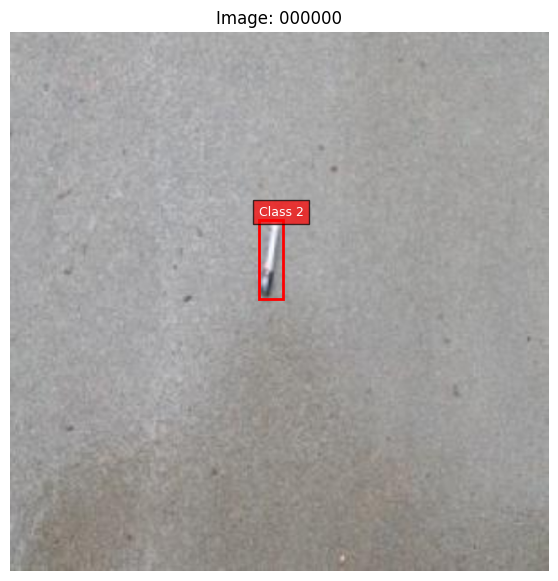

In [10]:
visualize_sample(
    train_dataset,
    index=0
)

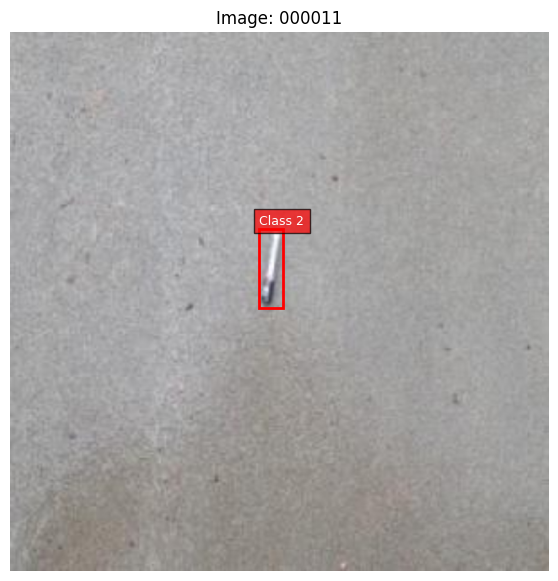

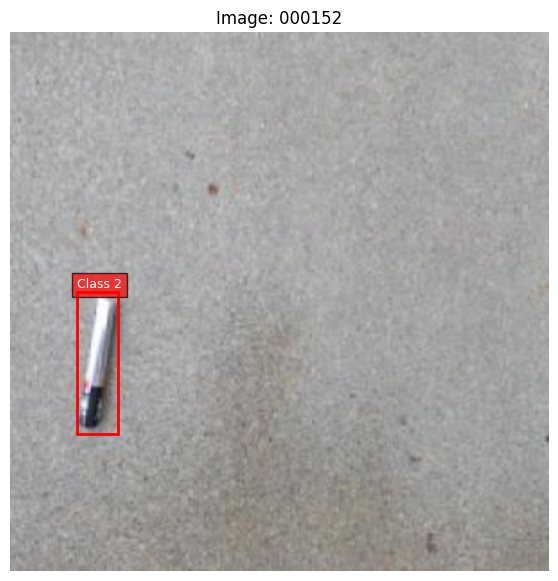

In [11]:
visualize_sample(
    train_dataset,
    index=10
)

visualize_sample(
    train_dataset,
    index=100
)

### ***Dataloader : (w/o agumentation)***

In [12]:
train_dataset, train_loader = create_dataloader(
    root_dir=YOLO_ROOT,
    split="train",
    img_size=640,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

In [13]:
val_dataset, val_loader = create_dataloader(
    root_dir=YOLO_ROOT,
    split="val",
    img_size=640,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [14]:
test_dataset, test_loader = create_dataloader(
    root_dir=YOLO_ROOT,
    split="test",
    img_size=640,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [15]:
images, targets = next(
    iter(train_loader)
)

In [16]:
print(
    "Images:",
    images.shape
)

print(
    "Number of targets:",
    len(targets)
)

Images: torch.Size([8, 3, 640, 640])
Number of targets: 8


In [17]:
for i, target in enumerate(targets):

    print(
        f"Image {i}:",
        target["image_id"],
        "| Objects:",
        len(target["labels"]),
        "| Boxes:",
        target["boxes"].shape
    )

Image 0: 030799 | Objects: 1 | Boxes: torch.Size([1, 4])
Image 1: 002749 | Objects: 1 | Boxes: torch.Size([1, 4])
Image 2: 021902 | Objects: 1 | Boxes: torch.Size([1, 4])
Image 3: 010452 | Objects: 1 | Boxes: torch.Size([1, 4])
Image 4: 029507 | Objects: 1 | Boxes: torch.Size([1, 4])
Image 5: 005866 | Objects: 1 | Boxes: torch.Size([1, 4])
Image 6: 021411 | Objects: 1 | Boxes: torch.Size([1, 4])
Image 7: 029247 | Objects: 1 | Boxes: torch.Size([1, 4])


### ***Dataloader (with agumentation)***

In [37]:
train_dataset, train_loader = create_dataloader(
    root_dir=YOLO_ROOT,
    split="train",
    img_size=640,
    batch_size=8,
    shuffle=True,
    augment=True,
    augmentation_strength=2
)

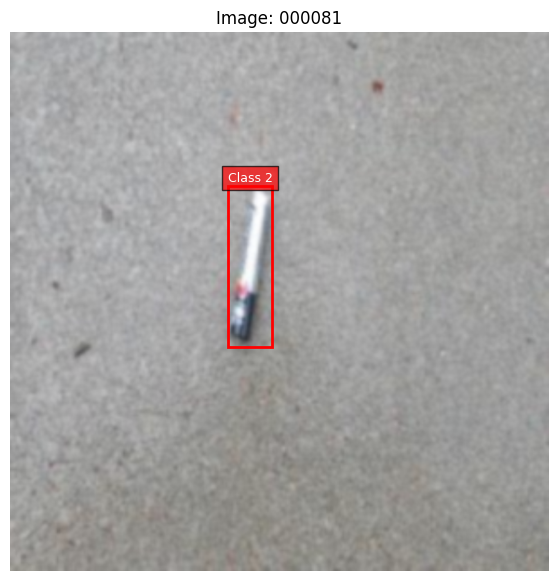

In [38]:
visualize_sample(
    train_dataset,
    index=53
)

In [39]:
val_dataset, val_loader = create_dataloader(
    root_dir=YOLO_ROOT,
    split="val",
    img_size=640,
    batch_size=8,
    shuffle=False,
    augment=False
)

test_dataset, test_loader = create_dataloader(
    root_dir=YOLO_ROOT,
    split="test",
    img_size=640,
    batch_size=8,
    shuffle=False,
    augment=False
)

In [40]:
images, targets = next(
    iter(train_loader)
)


print(
    "Images:",
    images.shape
)

print(
    "Number of targets:",
    len(targets)
)

Images: torch.Size([8, 3, 640, 640])
Number of targets: 8
